In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from function.library import *
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from interpret.glassbox import ExplainableBoostingClassifier
from pygam import LogisticGAM
import pymc as pm
import pytensor.tensor as pt

In [3]:
X_train = pd.read_csv('../data/X_train.csv')   
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("Number of original features:", X_train.shape[1])

X_train shape: (759384, 23)
y_train shape: (759384,)
Number of original features: 23


In [ ]:

def load_level2_row(csv_path):
    df = pd.read_csv(csv_path)

    level2 = df[
        df["Search Level"].astype(str).str.strip().str.lower() == "level 2"
    ]

    if level2.empty:
        raise ValueError(f"No Level 2 row found in: {csv_path}")

    if len(level2) > 1:
        raise ValueError(f"More than one Level 2 row found in: {csv_path}")

    return level2.iloc[0]


lr_level2 = load_level2_row("../results/lr_best_parameters.csv")
blr_level2 = load_level2_row("../results/blr_best_parameters.csv")
ebm_level2 = load_level2_row("../results/ebm_best_parameters.csv")
gam_level2 = load_level2_row("../results/gam_best_parameters.csv")

print("LR Level 2 parameters:")
print(lr_level2)

print("\nBLR Level 2 parameters:")
print(blr_level2)

print("\nEBM Level 2 parameters:")
print(ebm_level2)

print("\nGAM Level 2 parameters:")
print(gam_level2)


LR Level 2 parameters:
Search Level           Level 2
Best C                     0.2
Best Penalty                l1
Best Solver          liblinear
Best Mean ROC-AUC     0.918351
Name: 1, dtype: object

BLR Level 2 parameters:
Search Level          Level 2
Best prior_sd             2.0
Best Mean ROC-AUC    0.912627
Best Std ROC-AUC     0.000752
Name: 1, dtype: object

EBM Level 2 parameters:
Search Level                 Level 2
interactions                    1.5x
learning_rate                   0.04
max_leaves                         3
smoothing_rounds                  25
Best Mean CV ROC-AUC        0.978269
Tuning Time             16572.872904
Name: 1, dtype: object

GAM Level 2 parameters:
Search Level          Level 2
Best Lambda            0.0005
Best Mean ROC-AUC    0.926332
Best Std ROC-AUC      0.00144
Name: 1, dtype: object


In [ ]:

lr_params = {
    "C": float(lr_level2["Best C"]),
    "penalty": str(lr_level2["Best Penalty"]),
    "solver": str(lr_level2["Best Solver"])
}

blr_prior_sd = float(blr_level2["Best prior_sd"])

ebm_params = {
    "interactions": (ebm_level2["interactions"]),
    "learning_rate": float(ebm_level2["learning_rate"]),
    "smoothing_rounds": int(ebm_level2["smoothing_rounds"]),
    "max_leaves": int(ebm_level2["max_leaves"])
}

gam_lambda = float(gam_level2["Best Lambda"])

print("Final LR parameters:", lr_params)
print("Final BLR prior_sd:", blr_prior_sd)
print("Final EBM parameters:", ebm_params)
print("Final GAM lambda:", gam_lambda)


Final LR parameters: {'C': 0.2, 'penalty': 'l1', 'solver': 'liblinear'}
Final BLR prior_sd: 2.0
Final EBM parameters: {'interactions': '1.5x', 'learning_rate': 0.04, 'smoothing_rounds': 25, 'max_leaves': 3}
Final GAM lambda: 0.0005


In [ ]:

lr_rfe_estimator = LogisticRegression(
    C=lr_params["C"],
    penalty=lr_params["penalty"],
    solver=lr_params["solver"],
    max_iter=3000,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rfe = RFECV(
    estimator=lr_rfe_estimator,
    step=1,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2,
    min_features_to_select=1
)

start_time = time.time()
rfe.fit(X_train, y_train)
rfe_training_time = time.time() - start_time

print("\nRFE completed.")
print("RFE training time:", round(rfe_training_time, 2), "seconds")
print("Optimal number of features:", rfe.n_features_)



RFE completed.
RFE training time: 740.89 seconds
Optimal number of features: 23


In [8]:
selected_features = X_train.columns[rfe.support_].tolist()

X_train_rfe = X_train[selected_features].copy()
X_test_rfe = X_test[selected_features].copy()

print("Selected features:", len(selected_features))
for number, feature in enumerate(selected_features, start=1):
    print(f"{number}. {feature}")

print("\nX_train_rfe shape:", X_train_rfe.shape)
print("X_test_rfe shape:", X_test_rfe.shape)

Selected features: 23
1. annual_income
2. debt_to_income_ratio
3. credit_score
4. loan_amount
5. interest_rate
6. education_level
7. grade_subgrade
8. gender_Male
9. gender_Female
10. marital_status_Married
11. marital_status_Single
12. marital_status_Widowed
13. employment_status_Retired
14. employment_status_Self-employed
15. employment_status_Student
16. employment_status_Unemployed
17. loan_purpose_Car
18. loan_purpose_Debt consolidation
19. loan_purpose_Education
20. loan_purpose_Home
21. loan_purpose_Medical
22. loan_purpose_Other
23. loan_purpose_Vacation

X_train_rfe shape: (759384, 23)
X_test_rfe shape: (118799, 23)


In [9]:
joblib.dump(rfe, "../models/rfe_selector.pkl")
joblib.dump(selected_features, "../models/rfe_selected_features.pkl")

rfe_ranking_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
}).sort_values(["Ranking", "Feature"])

rfe_ranking_df.to_csv(
    "../results/rfe_feature_ranking.csv",
    index=False
)

rfe_summary_df = pd.DataFrame({
    "Item": [
        "Original Number of Features",
        "Selected Number of Features",
        "RFE Training Time"
    ],
    "Value": [
        X_train.shape[1],
        len(selected_features),
        rfe_training_time
    ]
})

rfe_summary_df.to_csv(
    "../results/rfe_summary.csv",
    index=False
)

print("RFE files saved successfully.")
rfe_ranking_df


RFE files saved successfully.


,Feature,Selected,Ranking
0,annual_income,True,1
2,credit_score,True,1
1,debt_to_income_ratio,True,1
5,education_level,True,1
12,employment_status_Retired,True,1
13,employment_status_Self-employed,True,1
14,employment_status_Student,True,1
15,employment_status_Unemployed,True,1
8,gender_Female,True,1
7,gender_Male,True,1


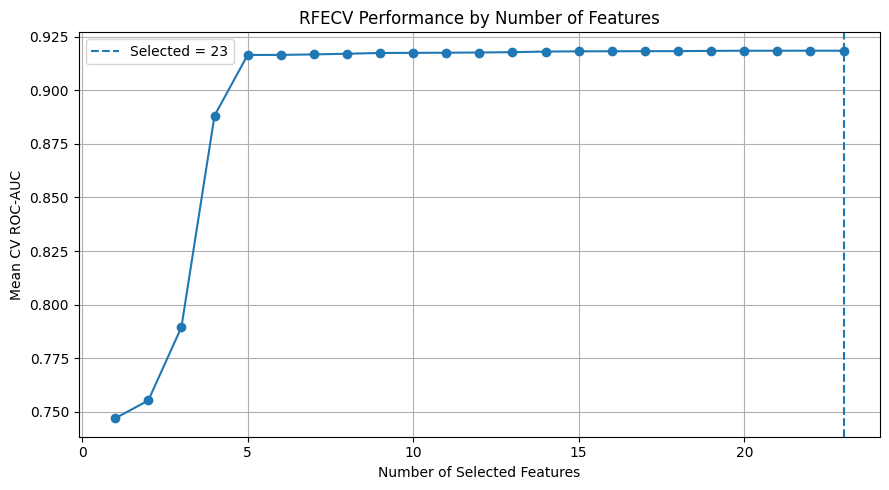

,Number of Features,Mean ROC-AUC,Std ROC-AUC
0,1,0.747028,0.000831
1,2,0.755355,0.000866
2,3,0.789540,0.000996
3,4,0.888136,0.000569
4,5,0.916427,0.000470
5,6,0.916460,0.000500
6,7,0.916684,0.000612
7,8,0.916994,0.000498
8,9,0.917366,0.000523
9,10,0.917411,0.000532


In [10]:
rfe_scores_df = pd.DataFrame({
    "Number of Features": range(
        rfe.min_features_to_select,
        rfe.min_features_to_select + len(rfe.cv_results_["mean_test_score"])
    ),
    "Mean ROC-AUC": rfe.cv_results_["mean_test_score"],
    "Std ROC-AUC": rfe.cv_results_["std_test_score"]
})

rfe_scores_df.to_csv(
    "../results/rfe_feature_selection_results.csv",
    index=False
)

plt.figure(figsize=(9, 5))
plt.plot(
    rfe_scores_df["Number of Features"],
    rfe_scores_df["Mean ROC-AUC"],
    marker="o"
)
plt.axvline(
    rfe.n_features_,
    linestyle="--",
    label=f"Selected = {rfe.n_features_}"
)
plt.xlabel("Number of Selected Features")
plt.ylabel("Mean CV ROC-AUC")
plt.title("RFECV Performance by Number of Features")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

rfe_scores_df


In [11]:
def evaluate_binary_model(model_name, y_true, y_pred, y_prob, training_time, num_features):
    y_true = np.asarray(y_true).astype(float).astype(int).ravel()
    y_pred = np.asarray(y_pred).astype(float).astype(int).ravel()
    
    y_prob = np.asarray(y_prob, dtype=float)
    y_prob = np.clip(y_prob, 1e-15, 1 - 1e-15)

    return {
        "Model": model_name,
        "Number of Features": num_features,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "Training Time": training_time
    }

all_rfe_results = []

In [12]:
def save_vertical_results(result, model_name, file_name):

    evaluation_df = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "Log Loss",
            "Brier Score",
            "Training Time"
        ],
        model_name: [
            result["Accuracy"],
            result["Precision"],
            result["Recall"],
            result["F1 Score"],
            result["ROC-AUC"],
            result["Log Loss"],
            result["Brier Score"],
            result["Training Time"]
        ]
    })

    evaluation_df.to_csv(
        file_name,
        index=False
    )

    return evaluation_df

In [ ]:

lr_rfe_model = LogisticRegression(
    C=lr_params["C"],
    penalty=lr_params["penalty"],
    solver=lr_params["solver"],
    max_iter=3000,
    random_state=42
)

start_time = time.time()
lr_rfe_model.fit(X_train_rfe, y_train)
lr_rfe_time = time.time() - start_time

y_pred_lr_rfe = lr_rfe_model.predict(X_test_rfe)
y_prob_lr_rfe = lr_rfe_model.predict_proba(X_test_rfe)[:, 1]

lr_rfe_result = evaluate_binary_model(
    "LR + RFE",
    y_test,
    y_pred_lr_rfe,
    y_prob_lr_rfe,
    lr_rfe_time,
    len(selected_features)
)

lr_rfe_df = save_vertical_results(
    lr_rfe_result,
    "LR + RFE",
    "../results/lr_rfe_evaluation_results.csv"
)

all_rfe_results.append(lr_rfe_result)

joblib.dump(lr_rfe_model, "../models/lr_rfe_model.pkl")

print("LR + RFE model and evaluation results saved successfully.")

lr_rfe_df


LR + RFE model and evaluation results saved successfully.


,Metric,LR + RFE
0,Accuracy,0.863324
1,Precision,0.936060
2,Recall,0.889485
3,F1 Score,0.912179
4,ROC-AUC,0.908984
5,Log Loss,0.344576
6,Brier Score,0.104507
7,Training Time,20.473465


In [ ]:

X_train_rfe_np = X_train_rfe.values.astype("float32")
X_test_rfe_np = X_test_rfe.values.astype("float32")
y_train_np = y_train.astype("int32")

n_rfe_features = X_train_rfe_np.shape[1]

start_time = time.time()

with pm.Model() as blr_rfe_pymc_model:
    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=blr_prior_sd
    )

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=blr_prior_sd,
        shape=n_rfe_features
    )

    logits = alpha + pt.dot(X_train_rfe_np, beta)

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(logits)
    )

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=y_train_np
    )

    approximation = pm.fit(
        n=20000,
        method="advi",
        random_seed=42,
        progressbar=False
    )

    blr_rfe_trace = approximation.sample(
        draws=1000,
        random_seed=42
    )

blr_rfe_time = time.time() - start_time

alpha_samples_rfe = (
    blr_rfe_trace.posterior["alpha"]
    .values
    .reshape(-1)
)

beta_samples_rfe = (
    blr_rfe_trace.posterior["beta"]
    .values
    .reshape(-1, n_rfe_features)
)

alpha_mean_rfe = alpha_samples_rfe.mean()
beta_mean_rfe = beta_samples_rfe.mean(axis=0)

blr_logits_test = alpha_mean_rfe + X_test_rfe_np @ beta_mean_rfe
y_prob_blr_rfe = expit(blr_logits_test)
y_pred_blr_rfe = (y_prob_blr_rfe >= 0.5).astype(int)

blr_rfe_result = evaluate_binary_model(
    "BLR + RFE",
    y_test,
    y_pred_blr_rfe,
    y_prob_blr_rfe,
    blr_rfe_time,
    len(selected_features)
)

blr_rfe_df = save_vertical_results(
    blr_rfe_result,
    "BLR + RFE",
    "../results/blr_rfe_evaluation_results.csv"
)

all_rfe_results.append(blr_rfe_result)

blr_rfe_model_data = {
    "alpha_mean": alpha_mean_rfe,
    "beta_mean": beta_mean_rfe,
    "alpha_samples": alpha_samples_rfe,
    "beta_samples": beta_samples_rfe,
    "best_prior_sd": blr_prior_sd,
    "columns": selected_features
}

joblib.dump(
    blr_rfe_model_data,
    "../models/blr_rfe_model.pkl"
)

print("BLR + RFE model and evaluation results saved successfully.")

blr_rfe_df


Finished [100%]: Average Loss = 2.7189e+05


BLR + RFE model and evaluation results saved successfully.


,Metric,BLR + RFE
0,Accuracy,0.863054
1,Precision,0.936960
2,Recall,0.888146
3,F1 Score,0.911900
4,ROC-AUC,0.910804
5,Log Loss,0.346522
6,Brier Score,0.105040
7,Training Time,2896.359409


In [ ]:

ebm_rfe_model = ExplainableBoostingClassifier(
    smoothing_rounds=ebm_params["smoothing_rounds"],
    learning_rate=ebm_params["learning_rate"],
    max_leaves=ebm_params["max_leaves"],
    interactions=ebm_params["interactions"],
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
ebm_rfe_model.fit(X_train_rfe, y_train)
ebm_rfe_time = time.time() - start_time

y_pred_ebm_rfe = ebm_rfe_model.predict(X_test_rfe)
y_prob_ebm_rfe = ebm_rfe_model.predict_proba(X_test_rfe)[:, 1]

ebm_rfe_result = evaluate_binary_model(
    "EBM + RFE",
    y_test,
    y_pred_ebm_rfe,
    y_prob_ebm_rfe,
    ebm_rfe_time,
    len(selected_features)
)

ebm_rfe_df = save_vertical_results(
    ebm_rfe_result,
    "EBM + RFE",
    "../results/ebm_rfe_evaluation_results.csv"
)

all_rfe_results.append(ebm_rfe_result)

joblib.dump(
    ebm_rfe_model,
    "../models/ebm_rfe_model.pkl"
)

ebm_rfe_importance_df = pd.DataFrame({
    "Term": ebm_rfe_model.term_names_,
    "Importance": ebm_rfe_model.term_importances()
}).sort_values(
    "Importance",
    ascending=False
)

ebm_rfe_importance_df.to_csv(
    "../results/ebm_rfe_feature_importance.csv",
    index=False
)

print("EBM + RFE model and evaluation results saved successfully.")

ebm_rfe_df


EBM + RFE model and evaluation results saved successfully.


,Metric,EBM + RFE
0,Accuracy,0.907987
1,Precision,0.914862
2,Recall,0.975475
3,F1 Score,0.944197
4,ROC-AUC,0.926530
5,Log Loss,0.239443
6,Brier Score,0.070035
7,Training Time,1977.768659


In [ ]:

gam_rfe_model = LogisticGAM(
    lam=gam_lambda,
    max_iter=500,
    tol=1e-4,
    verbose=False
)

start_time = time.time()
gam_rfe_model.fit(X_train_rfe.values, y_train)
gam_rfe_time = time.time() - start_time

y_prob_gam_rfe = gam_rfe_model.predict_proba(X_test_rfe.values)
y_pred_gam_rfe = (y_prob_gam_rfe >= 0.5).astype(int)

gam_rfe_result = evaluate_binary_model(
    "GAM + RFE",
    y_test,
    y_pred_gam_rfe,
    y_prob_gam_rfe,
    gam_rfe_time,
    len(selected_features)
)

gam_rfe_df = save_vertical_results(
    gam_rfe_result,
    "GAM + RFE",
    "../results/gam_rfe_evaluation_results.csv"
)

all_rfe_results.append(gam_rfe_result)

joblib.dump(
    gam_rfe_model,
    "../models/gam_rfe_model.pkl"
)

print("GAM + RFE model and evaluation results saved successfully.")

gam_rfe_df


GAM + RFE model and evaluation results saved successfully.


,Metric,GAM + RFE
0,Accuracy,0.867432
1,Precision,0.936357
2,Recall,0.894686
3,F1 Score,0.915047
4,ROC-AUC,0.909665
5,Log Loss,0.331237
6,Brier Score,0.101636
7,Training Time,2609.430108


In [ ]:

all_rfe_results = [
    lr_rfe_result,
    blr_rfe_result,
    ebm_rfe_result,
    gam_rfe_result
]

rfe_model_comparison_df = pd.DataFrame(all_rfe_results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Log Loss",
    "Brier Score",
    "Training Time"
]

for column in metric_columns:
    rfe_model_comparison_df[column] = pd.to_numeric(
        rfe_model_comparison_df[column],
        errors="coerce"
    )

rfe_model_comparison_df.to_csv(
    "../results/rfe_models_comparison.csv",
    index=False
)

print("All RFE-based models and results saved successfully.")
rfe_model_comparison_df


All RFE-based models and results saved successfully.


,Model,Number of Features,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Log Loss,Brier Score,Training Time
0,LR + RFE,23,0.863324,0.936060,0.889485,0.912179,0.908984,0.344576,0.104507,20.473465
1,BLR + RFE,23,0.863054,0.936960,0.888146,0.911900,0.910804,0.346522,0.105040,2896.359409
2,EBM + RFE,23,0.907987,0.914862,0.975475,0.944197,0.926530,0.239443,0.070035,1977.768659
3,GAM + RFE,23,0.867432,0.936357,0.894686,0.915047,0.909665,0.331237,0.101636,2609.430108


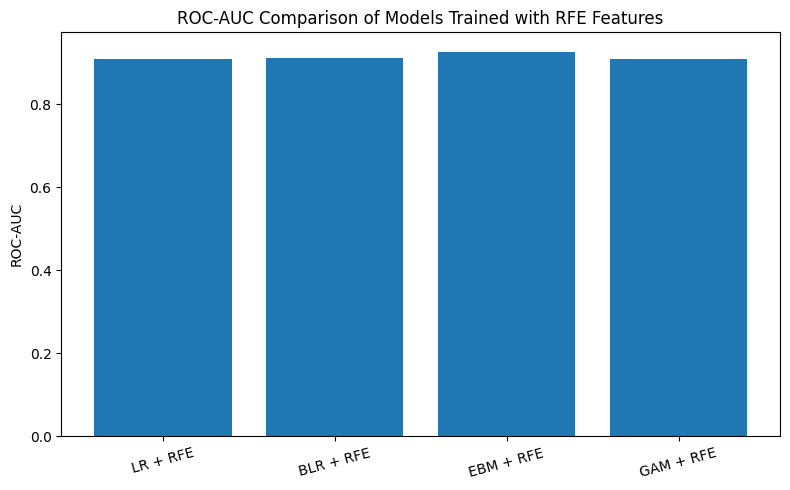

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(
    rfe_model_comparison_df["Model"],
    rfe_model_comparison_df["ROC-AUC"]
)
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison of Models Trained with RFE Features")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
